In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/gokulrajkmv/unemployment-in-india/Unemployment_Rate_upto_11_2020.csv
/kaggle/input/datasets/gokulrajkmv/unemployment-in-india/Unemployment in India.csv


In [2]:
import os
print(os.listdir("/kaggle/input"))

['datasets']


In [3]:
import os
for root, dirs, files in os.walk("/kaggle/input"):
    for f in files:
        print(os.path.join(root, f))

/kaggle/input/datasets/gokulrajkmv/unemployment-in-india/Unemployment_Rate_upto_11_2020.csv
/kaggle/input/datasets/gokulrajkmv/unemployment-in-india/Unemployment in India.csv


In [4]:
import pandas as pd
df = pd.read_csv("/kaggle/input/datasets/gokulrajkmv/unemployment-in-india/Unemployment in India.csv")
df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [5]:
df.info()
df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    object 
 1    Date                                     740 non-null    object 
 2    Frequency                                740 non-null    object 
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    object 
dtypes: float64(3), object(4)
memory usage: 42.1+ KB


Index(['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)',
       ' Estimated Employed', ' Estimated Labour Participation Rate (%)',
       'Area'],
      dtype='object')

In [6]:
df.columns = df.columns.str.strip()

In [7]:
df.isnull().sum()

Region                                     28
Date                                       28
Frequency                                  28
Estimated Unemployment Rate (%)            28
Estimated Employed                         28
Estimated Labour Participation Rate (%)    28
Area                                       28
dtype: int64

In [8]:
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

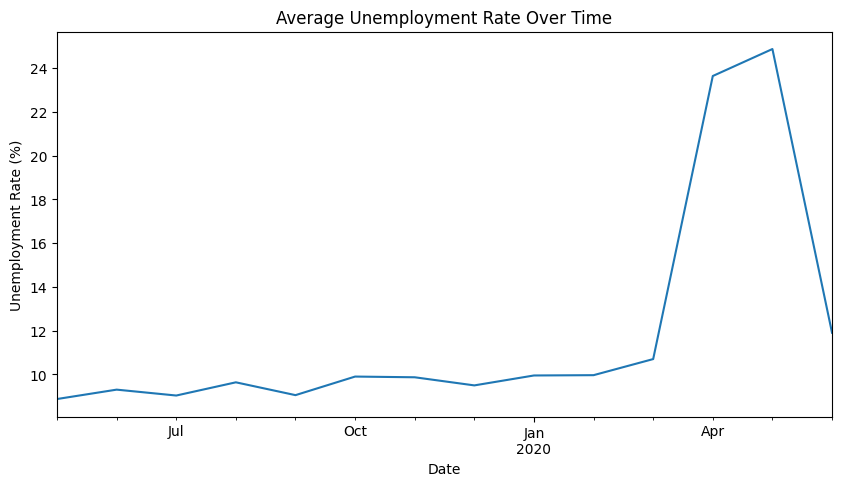

In [9]:
import matplotlib.pyplot as plt
df.groupby('Date')['Estimated Unemployment Rate (%)'].mean().plot(figsize=(10,5))
plt.title("Average Unemployment Rate Over Time")
plt.ylabel("Unemployment Rate (%)")
plt.show()

In [10]:
top_states = df.groupby('Region')['Estimated Unemployment Rate (%)'].mean().sort_values(ascending=False)
top_states.head(10)

Region
Tripura             28.350357
Haryana             26.283214
Jharkhand           20.585000
Bihar               18.918214
Himachal Pradesh    18.540357
Delhi               16.495357
Jammu & Kashmir     16.188571
Chandigarh          15.991667
Rajasthan           14.058214
Uttar Pradesh       12.551429
Name: Estimated Unemployment Rate (%), dtype: float64

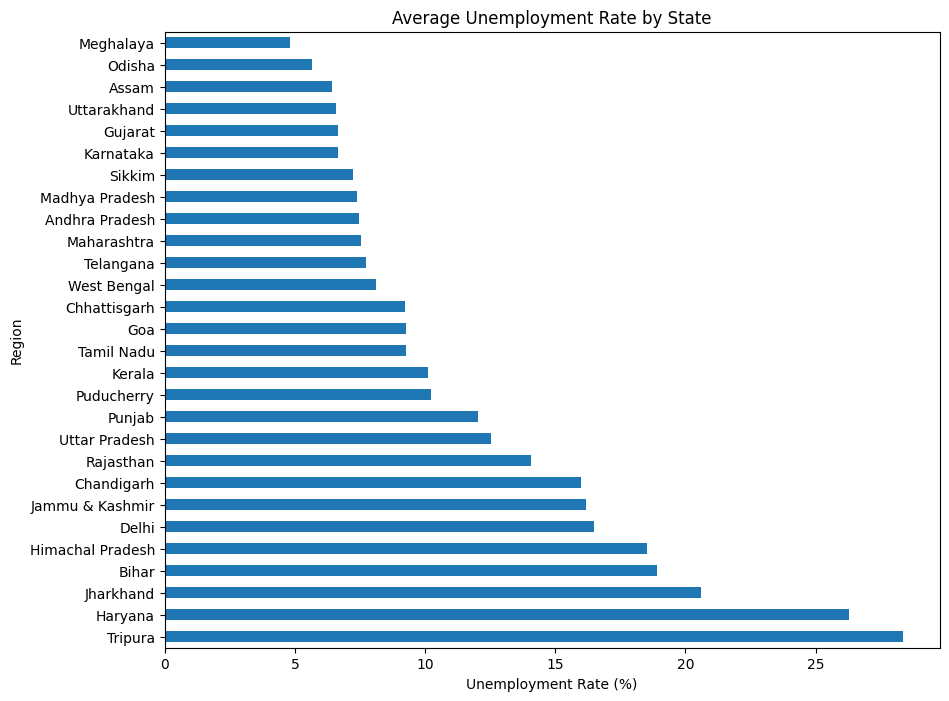

In [11]:
plt.figure(figsize=(10,8))
top_states.plot(kind='barh')
plt.title("Average Unemployment Rate by State")
plt.xlabel("Unemployment Rate (%)")
plt.show()

In [12]:
df['Period'] = df['Date'].apply(lambda x: 'Pre-Covid' if x < pd.to_datetime('2020-03-01') else 'Covid')
df.groupby('Period')['Estimated Unemployment Rate (%)'].mean()

Period
Covid        17.774363
Pre-Covid     9.509534
Name: Estimated Unemployment Rate (%), dtype: float64

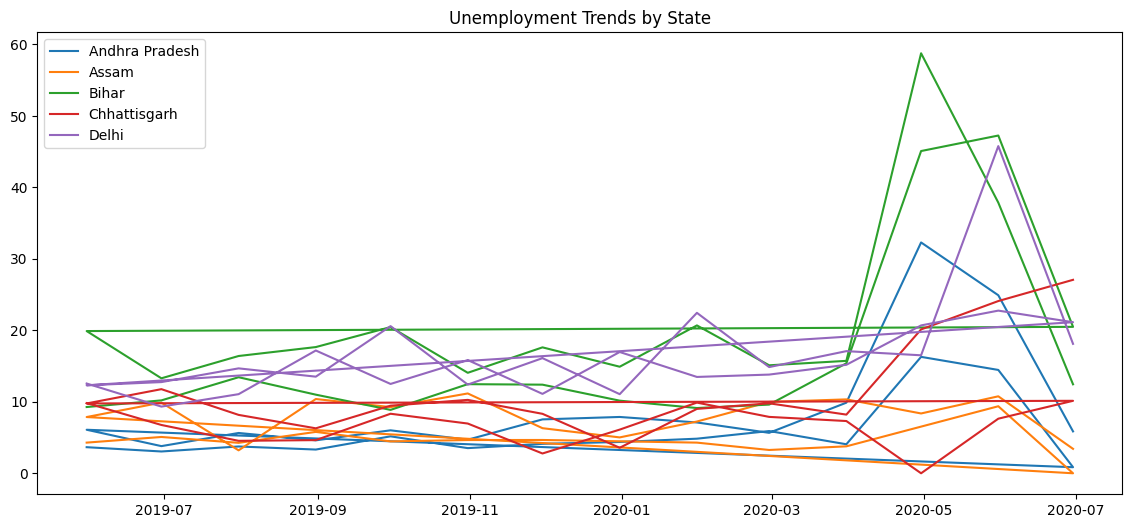

In [13]:
plt.figure(figsize=(14,6))
for region in df['Region'].unique()[:5]:  # first 5 states as example
    subset = df[df['Region'] == region]
    plt.plot(subset['Date'], subset['Estimated Unemployment Rate (%)'], label=region)
plt.legend()
plt.title("Unemployment Trends by State")
plt.show()

## Key Insights

- Unemployment in India remained stable around 8–10% before March 2020.
- After the Covid-19 lockdown in April 2020, the national average unemployment rate spiked sharply to over 24%, before gradually recovering.
- Bihar and Delhi experienced the most severe spikes, with Bihar peaking near 60%.
- Assam and Chhattisgarh remained comparatively stable throughout, suggesting more resilient local economies.
- These findings suggest targeted economic relief should prioritize states with high urban/migrant labor dependency during future shocks.